In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
DATA_PATH = r"data/hdfc/HDFCBANK.csv"
COMPANY_NAME = "HDFC Bank"

df = pd.read_csv(DATA_PATH)
df["Date"] = pd.to_datetime(df["Date"])
df.head()

,Date,Adj Close,Close,High,Low,Open,Volume
0,2010-01-04,73.725166,85.285004,86.425003,84.627502,85.000000,6100980
1,2010-01-05,73.790001,85.360001,86.250000,85.250000,85.500000,16773200
2,2010-01-06,73.839699,85.417503,86.000000,84.404999,85.699997,13279680
3,2010-01-07,74.032036,85.639999,88.419998,85.080002,88.419998,12247960
4,2010-01-08,74.129295,85.752502,86.169998,85.050003,85.599998,14171800


General

In [4]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nDate range:")
print(df["Date"].min(), "to", df["Date"].max())

Shape: (4131, 7)

Columns:
['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']

Data types:
Date         datetime64[us]
Adj Close           float64
Close               float64
High                float64
Low                 float64
Open                float64
Volume                int64
dtype: object

Date range:
2010-01-04 00:00:00 to 2026-09-21 00:00:00


Trend

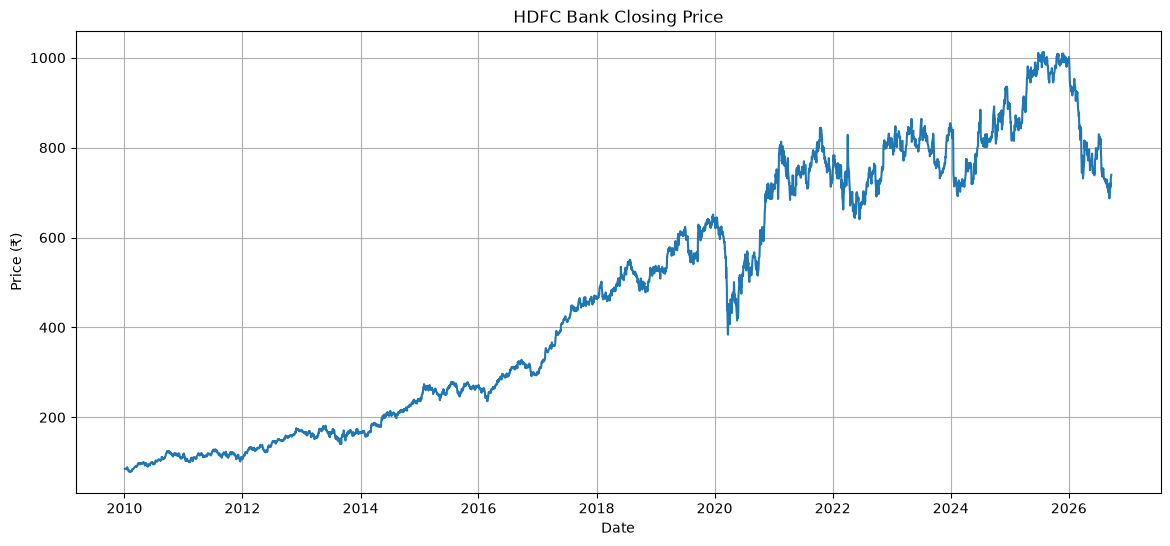

In [5]:
plt.figure(figsize=(14, 6))
plt.plot(df["Date"], df["Close"])
plt.title(f"{COMPANY_NAME} Closing Price")
plt.xlabel("Date")
plt.ylabel("Price (₹)")
plt.grid(True)
plt.show()

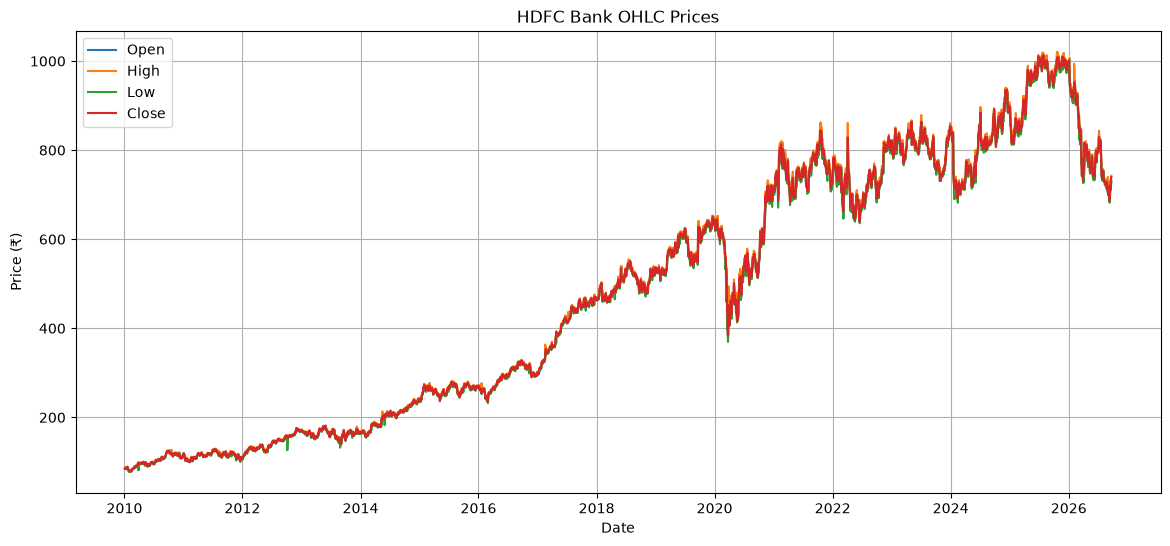

In [6]:
plt.figure(figsize=(14, 6))

plt.plot(df["Date"], df["Open"], label="Open")
plt.plot(df["Date"], df["High"], label="High")
plt.plot(df["Date"], df["Low"], label="Low")
plt.plot(df["Date"], df["Close"], label="Close")

plt.title(f"{COMPANY_NAME} OHLC Prices")
plt.xlabel("Date")
plt.ylabel("Price (₹)")
plt.legend()
plt.grid(True)
plt.show()

Volume

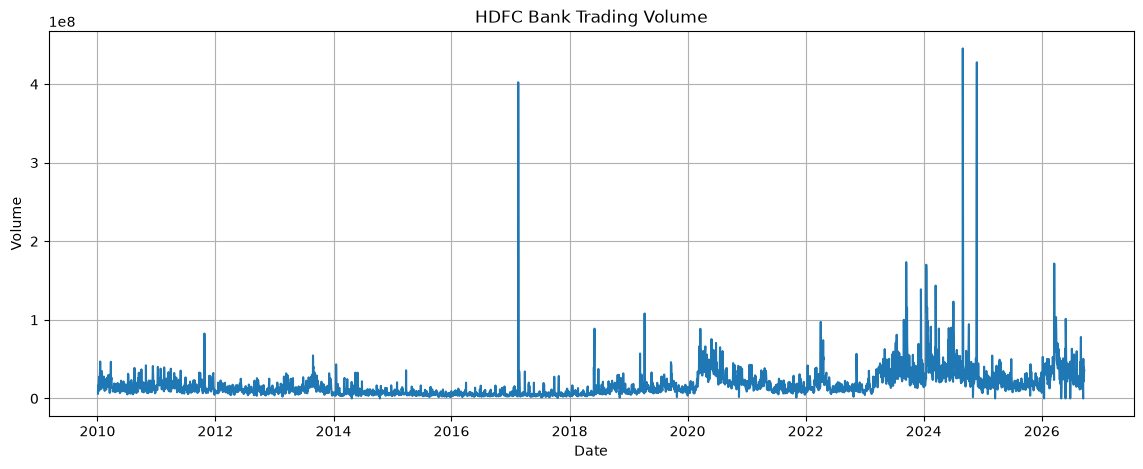

In [7]:
plt.figure(figsize=(14, 5))

plt.plot(df["Date"], df["Volume"])

plt.title(f"{COMPANY_NAME} Trading Volume")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.grid(True)
plt.show()

In [8]:
df["Volume"].describe()

count    4.131000e+03
mean     1.710733e+07
std      1.849861e+07
min      0.000000e+00
25%      7.403280e+06
50%      1.237572e+07
75%      2.107560e+07
max      4.453421e+08
Name: Volume, dtype: float64

Returns

In [9]:
df["Return"] = df["Close"].pct_change()

df[["Date", "Close", "Return"]].head(10)

,Date,Close,Return
0,2010-01-04,85.285004,NaN
1,2010-01-05,85.360001,0.000879
2,2010-01-06,85.417503,0.000674
3,2010-01-07,85.639999,0.002605
4,2010-01-08,85.752502,0.001314
5,2010-01-11,85.407501,-0.004023
6,2010-01-12,84.760002,-0.007581
7,2010-01-13,84.464996,-0.003480
8,2010-01-14,84.190002,-0.003256
9,2010-01-15,84.707497,0.006147


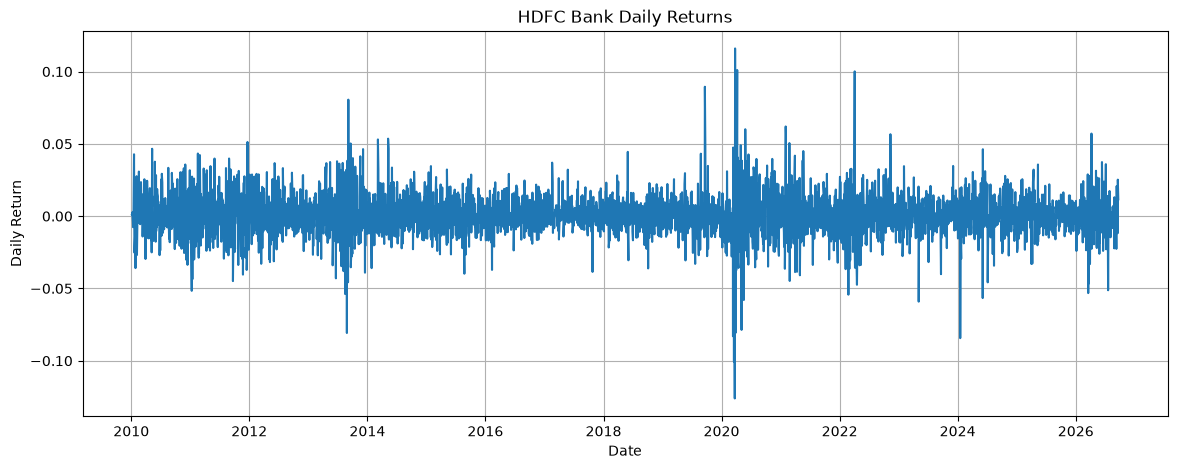

In [10]:
plt.figure(figsize=(14, 5))

plt.plot(df["Date"], df["Return"])

plt.title(f"{COMPANY_NAME} Daily Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.grid(True)
plt.show()

In [11]:
df["Return"].describe()

count    4130.000000
mean        0.000628
std         0.014457
min        -0.126069
25%        -0.007009
50%         0.000333
75%         0.007744
max         0.115996
Name: Return, dtype: float64

Annual Volatility

In [12]:
annual_volatility = df["Return"].std() * np.sqrt(252)

print(f"Annualized volatility: {annual_volatility:.2%}")

Annualized volatility: 22.95%


Simple Moving Averages

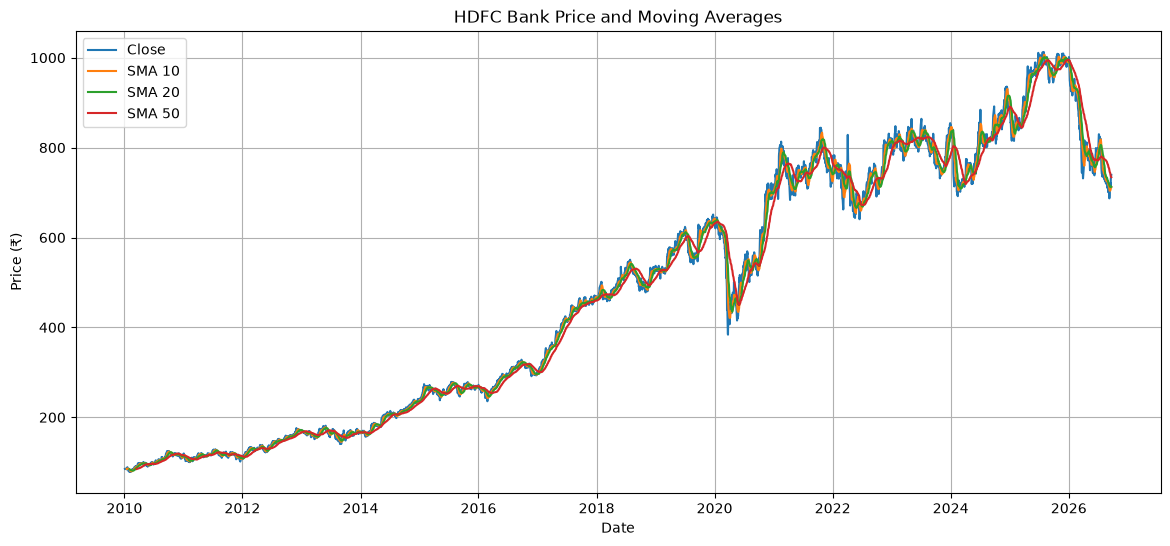

In [13]:
df["SMA_10"] = df["Close"].rolling(10).mean()
df["SMA_20"] = df["Close"].rolling(20).mean()
df["SMA_50"] = df["Close"].rolling(50).mean()

plt.figure(figsize=(14, 6))

plt.plot(df["Date"], df["Close"], label="Close")
plt.plot(df["Date"], df["SMA_10"], label="SMA 10")
plt.plot(df["Date"], df["SMA_20"], label="SMA 20")
plt.plot(df["Date"], df["SMA_50"], label="SMA 50")

plt.title(f"{COMPANY_NAME} Price and Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price (₹)")
plt.legend()
plt.grid(True)
plt.show()

Exponential Moving Averages

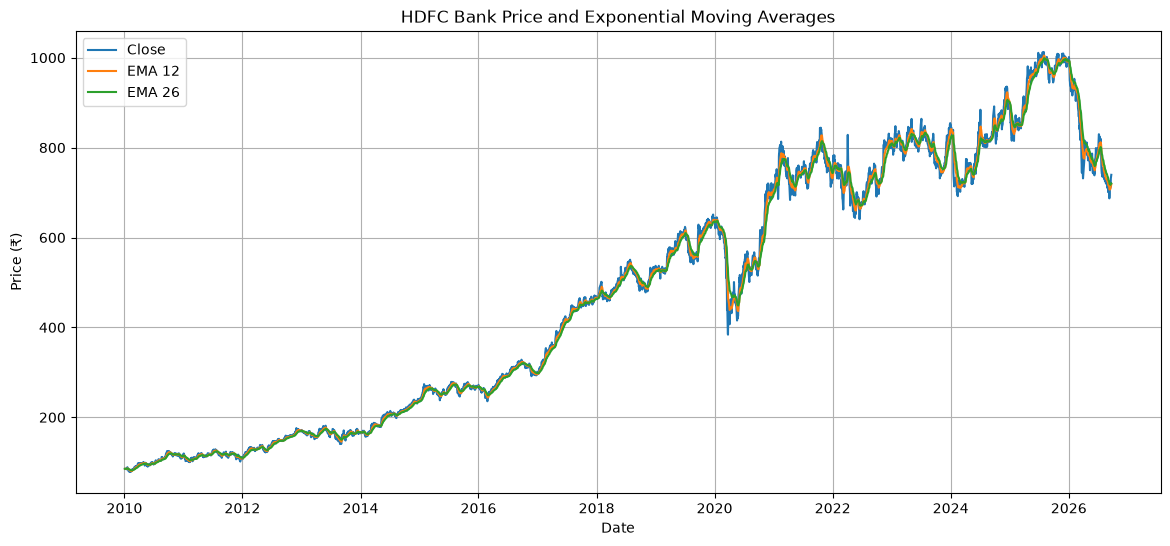

In [14]:
df["EMA_12"] = df["Close"].ewm(span=12, adjust=False).mean()
df["EMA_26"] = df["Close"].ewm(span=26, adjust=False).mean()

plt.figure(figsize=(14, 6))

plt.plot(df["Date"], df["Close"], label="Close")
plt.plot(df["Date"], df["EMA_12"], label="EMA 12")
plt.plot(df["Date"], df["EMA_26"], label="EMA 26")

plt.title(f"{COMPANY_NAME} Price and Exponential Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price (₹)")
plt.legend()
plt.grid(True)
plt.show()

Twenty Day Rolling Volitality

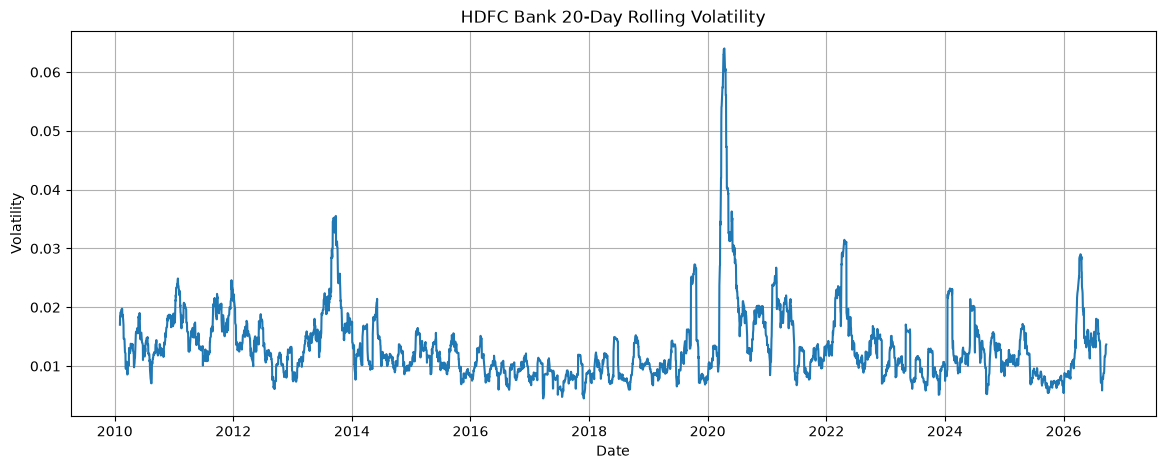

In [15]:
df["Volatility_20"] = df["Return"].rolling(20).std()

plt.figure(figsize=(14, 5))

plt.plot(df["Date"], df["Volatility_20"])

plt.title(f"{COMPANY_NAME} 20-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.grid(True)
plt.show()

Correlation

In [16]:
features = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "Return",
    "SMA_10",
    "SMA_20",
    "SMA_50",
    "EMA_12",
    "EMA_26",
    "Volatility_20",
]

df[features].corr()

,Open,High,Low,Close,Volume,Return,SMA_10,SMA_20,SMA_50,EMA_12,EMA_26,Volatility_20
Open,1.000000,0.999867,0.999866,0.999739,0.328246,-0.027166,0.999106,0.998041,0.995031,0.999229,0.998160,-0.121506
High,0.999867,1.000000,0.999818,0.999892,0.331512,-0.018765,0.999107,0.998086,0.995180,0.999246,0.998224,-0.117551
Low,0.999866,0.999818,1.000000,0.999876,0.324835,-0.019475,0.999020,0.997913,0.994831,0.999149,0.998029,-0.126610
Close,0.999739,0.999892,0.999876,1.000000,0.327733,-0.011270,0.998998,0.997941,0.994960,0.999145,0.998072,-0.122234
Volume,0.328246,0.331512,0.324835,0.327733,1.000000,0.007084,0.331092,0.337380,0.349196,0.331301,0.335697,0.257296
Return,-0.027166,-0.018765,-0.019475,-0.011270,0.007084,1.000000,-0.031917,-0.033340,-0.030989,-0.030026,-0.031132,0.020208
SMA_10,0.999106,0.999107,0.999020,0.998998,0.331092,-0.031917,1.000000,0.999446,0.996692,0.999938,0.999384,-0.121322
SMA_20,0.998041,0.998086,0.997913,0.997941,0.337380,-0.033340,0.999446,1.000000,0.998145,0.999623,0.999859,-0.117011
SMA_50,0.995031,0.995180,0.994831,0.994960,0.349196,-0.030989,0.996692,0.998145,1.000000,0.997196,0.998835,-0.097064
EMA_12,0.999229,0.999246,0.999149,0.999145,0.331301,-0.030026,0.999938,0.999623,0.997196,1.000000,0.999605,-0.119884


<Axes: >

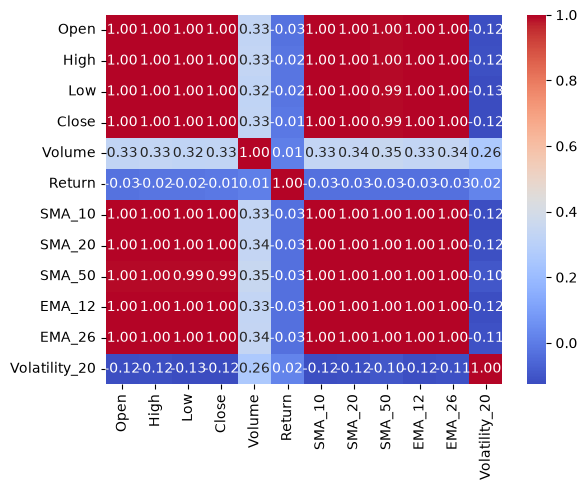

In [17]:
sns.heatmap(df[features].corr(), annot=True, fmt=".2f", cmap="coolwarm", cbar=True)

In [18]:
df.tail()

,Date,Adj Close,Close,High,Low,Open,Volume,Return,SMA_10,SMA_20,SMA_50,EMA_12,EMA_26,Volatility_20
4126,2026-09-15,716.549988,716.549988,730.750000,715.049988,722.400024,50387632,0.011719,704.699994,712.744998,741.484000,708.576967,717.828524,0.011875
4127,2026-09-16,721.500000,721.500000,725.400024,710.849976,714.900024,27476943,0.006908,706.769995,712.819998,739.708000,710.565126,718.100485,0.011948
4128,2026-09-17,713.000000,713.000000,719.400024,713.000000,717.500000,21543303,-0.011781,707.404993,712.217499,737.617001,710.939722,717.722672,0.012119
4129,2026-09-18,731.000000,731.000000,733.799988,715.250000,715.250000,39400710,0.025245,709.294995,712.419998,735.738000,714.025918,718.706177,0.013437
4130,2026-09-21,739.500000,739.500000,742.650024,729.049988,731.000000,35482683,0.011628,712.194995,712.944998,734.169000,717.945008,720.246461,0.013664


In [19]:
df[features].describe().T

,count,mean,std,min,25%,50%,75%,max
Open,4131.0,4.761929e+02,2.843367e+02,78.339996,1.785312e+02,4.755125e+02,7.475000e+02,1.018850e+03
High,4131.0,4.804520e+02,2.866005e+02,78.894997,1.804750e+02,4.804375e+02,7.550000e+02,1.020500e+03
Low,4131.0,4.718382e+02,2.822288e+02,77.449997,1.767625e+02,4.695000e+02,7.410625e+02,1.008500e+03
Close,4131.0,4.761886e+02,2.843457e+02,78.370003,1.789250e+02,4.758250e+02,7.474125e+02,1.012900e+03
Volume,4131.0,1.710733e+07,1.849861e+07,0.000000,7.403280e+06,1.237572e+07,2.107560e+07,4.453421e+08
Return,4130.0,6.276149e-04,1.445672e-02,-0.126069,-7.009082e-03,3.327796e-04,7.744457e-03,1.159958e-01
SMA_10,4122.0,4.763482e+02,2.840809e+02,79.680501,1.778072e+02,4.752425e+02,7.482463e+02,1.006850e+03
SMA_20,4112.0,4.765428e+02,2.838268e+02,81.070000,1.779630e+02,4.763534e+02,7.468278e+02,1.001265e+03
SMA_50,4082.0,4.770759e+02,2.830177e+02,84.808300,1.780353e+02,4.768050e+02,7.510993e+02,9.957550e+02
EMA_12,4131.0,4.753463e+02,2.842765e+02,80.362797,1.757449e+02,4.739483e+02,7.486427e+02,1.004847e+03


The correlation analysis indicates strong multicollinearity among OHLC and moving-average-based features. However, these features capture different aspects of price and trend information. To maintain a compact observation space while retaining market, trend, momentum, and volatility information, the final RL state will use Close, Volume, Return, SMA-20, SMA-50, EMA-12, EMA-26, and 20-day volatility. Feature scaling and relative transformations will be performed using the training data during model development.